# RT-DETR-L — Training on Brackish Dataset

Третья архитектура для сравнения. Параметры максимально приближены к v8s / yolo26s
(те же 30 эпох, imgsz=640, weak augmentation), кроме:

- **batch=16** вместо 32 — RT-DETR-L (32M params, transformer encoder + 300 query tokens)
  не помещается в 16 GB VRAM 5060 Ti при batch=32 даже с AMP. Это объективное
  ограничение памяти, не выбор гиперпараметра.
- **lr / optimizer**: не переопределяю — пусть ultralytics использует свои дефолты
  для RT-DETR (AdamW), иначе сравнение превратится в «архитектура + кастомный lr».

In [1]:
import os
from pathlib import Path
from ultralytics import RTDETR

if Path.cwd().name == "notebooks":
    os.chdir("..")
print(f"Working dir: {Path.cwd()}")

import torch
print(f"PyTorch:     {torch.__version__}")
print(f"CUDA:        {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

Working dir: d:\Slermo\Programming\Python\yolo_marine
PyTorch:     2.10.0+cu128
CUDA:        True — NVIDIA GeForce RTX 5060 Ti


In [2]:
model = RTDETR("rtdetr-l.pt")

model.train(
    data="configs/dataset.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    patience=10,
    device=0,
    workers=4,
    seed=42,
    amp=True,
    # weak augmentation — то же, что у v8s-weak и yolo26s-weak
    fliplr=0.5,
    hsv_h=0.014,
    hsv_s=0.1,
    hsv_v=0.1,
    degrees=0,
    translate=0.0,
    scale=0.0,
    # output
    project="../runs/rtdetr",
    name="weak",
)

New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.19  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=configs/dataset.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.014, hsv_s=0.1, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weak, nbs=6

d:\Slermo\Programming\Python\yolo_marine\.venv\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      12.2G     0.7847      3.168     0.2116         29        640: 100% ━━━━━━━━━━━━ 734/734 1.4it/s 8:37<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 2.2it/s 20.5s0.4s
                   all       1467       3581      0.787      0.725      0.731       0.48

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


d:\Slermo\Programming\Python\yolo_marine\.venv\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/30      12.1G     0.4356     0.4625     0.0954         34        640: 100% ━━━━━━━━━━━━ 734/734 1.6it/s 7:51<0.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 2.8it/s 16.5s0.4s
                   all       1467       3581      0.921      0.877      0.904      0.646

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/30      12.4G     0.4019     0.4281    0.08376         41        640: 0% ──────────── 0/734  0.9s

...

d:\Slermo\Programming\Python\yolo_marine\.venv\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      29/30      12.3G    0.09117     0.1589    0.01649         26        640: 100% ━━━━━━━━━━━━ 734/734 1.6it/s 7:41<0.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 2.8it/s 16.5s0.4s
                   all       1467       3581      0.989      0.985      0.993      0.857

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      30/30      12.3G     0.1285      0.185    0.03101         48        640: 0% ──────────── 0/734  0.8s

d:\Slermo\Programming\Python\yolo_marine\.venv\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      30/30      12.3G    0.08597      0.152    0.01551         41        640: 100% ━━━━━━━━━━━━ 734/734 1.6it/s 7:41<0.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 2.8it/s 16.5s0.4s
                   all       1467       3581      0.988      0.991      0.993      0.857

30 epochs completed in 4.052 hours.
Optimizer stripped from D:\Slermo\Programming\Python\yolo_marine\runs\runs\rtdetr\weak\weights\last.pt, 66.2MB
Optimizer stripped from D:\Slermo\Programming\Python\yolo_marine\runs\runs\rtdetr\weak\weights\best.pt, 66.2MB

Validating D:\Slermo\Programming\Python\yolo_marine\runs\runs\rtdetr\weak\weights\best.pt...
Ultralytics 8.4.19  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
rt-detr-l summary: 310 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 2.7it/s 17

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C9C5023110>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

## Results

Reading: runs\runs\rtdetr\weak\results.csv


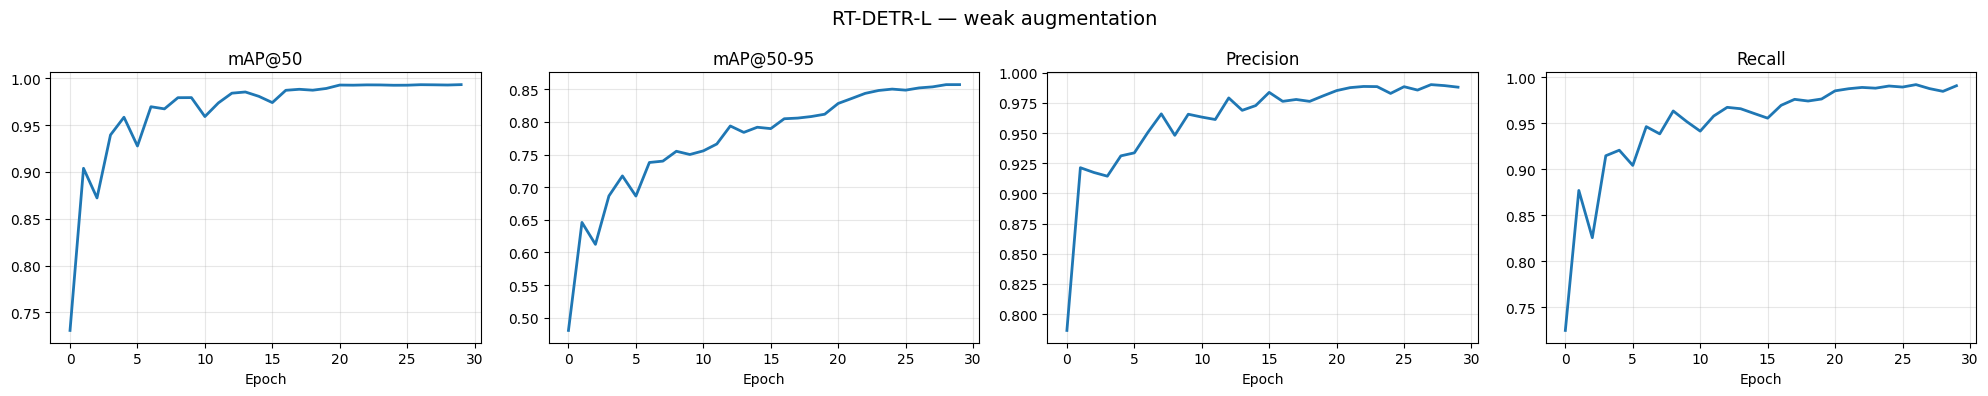


Best mAP@50:    0.9933  (epoch 30)
Best mAP@50-95: 0.8573  (epoch 30)


In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

candidates = sorted(
    Path("runs/runs/rtdetr").glob("weak*/results.csv"),
    key=lambda p: p.stat().st_mtime,
)
if not candidates:
    raise FileNotFoundError("results.csv не найден — возможно, обучение упало.")
RESULTS_CSV = candidates[-1]
print(f"Reading: {RESULTS_CSV}")

df = pd.read_csv(RESULTS_CSV, skipinitialspace=True)

metrics = {
    "mAP@50":    "metrics/mAP50(B)",
    "mAP@50-95": "metrics/mAP50-95(B)",
    "Precision": "metrics/precision(B)",
    "Recall":    "metrics/recall(B)",
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (title, col) in zip(axes, metrics.items()):
    ax.plot(df[col], linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)

plt.suptitle("RT-DETR-L — weak augmentation", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nBest mAP@50:    {df[metrics['mAP@50']].max():.4f}  (epoch {df[metrics['mAP@50']].argmax() + 1})")
print(f"Best mAP@50-95: {df[metrics['mAP@50-95']].max():.4f}  (epoch {df[metrics['mAP@50-95']].argmax() + 1})")

## Evaluate on test set

In [5]:
weights_candidates = sorted(
    Path("runs/runs/rtdetr").glob("weak*/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
)
WEIGHTS = weights_candidates[-1]
print(f"Using: {WEIGHTS}")

best = RTDETR(str(WEIGHTS))

metrics = best.val(
    data="configs/dataset.yaml",
    split="test",
    batch=1,
    device=0,
    plots=True,
)

print(f"mAP@50:      {metrics.box.map50:.4f}")
print(f"mAP@50-95:   {metrics.box.map:.4f}")
print(f"Precision:   {metrics.box.mp:.4f}")
print(f"Recall:      {metrics.box.mr:.4f}")

print(f"\nInference speed: {metrics.speed}")

print("\nPer-class AP@50:")
for i, name in metrics.names.items():
    print(f"  {name:12s}  {metrics.box.ap50[i]:.4f}")

Using: runs\runs\rtdetr\weak\weights\best.pt
Ultralytics 8.4.19  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
rt-detr-l summary: 310 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access  (ping: 5.37.0 ms, read: 15.25.0 MB/s, size: 405.4 KB)
val: Scanning D:\Slermo\Programming\Python\yolo_marine\data\brackish-dataset\labels\test.cache... 1468 images, 229 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1468/1468  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1468/1468 27.5it/s 53.4s<0.1s
                   all       1468       3466      0.985      0.977      0.987      0.844
                  fish        321        321      0.991      0.986      0.995       0.89
            small_fish        247        965      0.965      0.969      0.979      0.748
                  crab        614       1279      0.998      0.995      0.995      0.951
                shrimp         

## Continue training to convergence

На 30 эпохах кривая mAP@50-95 ещё росла (best был на последней эпохе) — DETR-семейство
известно тем, что требует длинного обучения. Дообучаем тот же ран до 60 эпох через
`resume=True`: ultralytics поднимет состояние оптимизатора, LR-планировщика и random state
и продолжит ровно с того места.

**Технический момент.** ultralytics проверяет «обучение завершено» по полю `train_args.epochs`,
которое лежит **внутри `last.pt`**, а не в `args.yaml`. Правка yaml-файла на эту проверку
не влияет — нужно патчить сам чекпоинт через `torch.load` / `torch.save`. На всякий случай
обновляем и `args.yaml` тоже, чтобы оба источника были согласованы.

После прогона этой ячейки перезапусти ячейки **Results** и **Evaluate on test set** —
они автоматически подхватят расширенные `results.csv` и обновлённый `best.pt`.

In [ ]:
import yaml
import torch
from ultralytics import RTDETR

NEW_EPOCHS = 60
NEW_PATIENCE = 20  # было 10 — даём DETR больше шанса на неровную кривую

run_dirs = sorted(Path("runs/runs/rtdetr").glob("weak*"), key=lambda p: p.stat().st_mtime)
if not run_dirs:
    raise FileNotFoundError("Не найден run RT-DETR — сначала запусти первоначальное обучение.")
run_dir = run_dirs[-1]
ckpt_path = run_dir / "weights" / "last.pt"

# 1) Главное — патчим last.pt: ultralytics берёт epochs отсюда при resume
ckpt = torch.load(ckpt_path, weights_only=False)
old_epochs = ckpt["train_args"]["epochs"]
if NEW_EPOCHS <= old_epochs:
    raise ValueError(f"NEW_EPOCHS ({NEW_EPOCHS}) должен быть больше текущих {old_epochs}")

ckpt["train_args"]["epochs"] = NEW_EPOCHS
ckpt["train_args"]["patience"] = NEW_PATIENCE
torch.save(ckpt, ckpt_path)

# 2) Заодно синхронизируем args.yaml — для согласованности логов
args_path = run_dir / "args.yaml"
with args_path.open() as f:
    args = yaml.safe_load(f)
args["epochs"] = NEW_EPOCHS
args["patience"] = NEW_PATIENCE
with args_path.open("w") as f:
    yaml.safe_dump(args, f)

print(f"Resuming {run_dir}")
print(f"  epochs:   {old_epochs} -> {NEW_EPOCHS}")
print(f"  patience: -> {NEW_PATIENCE}")
print(f"  last completed epoch in ckpt: {ckpt.get('epoch')}")

model = RTDETR(str(ckpt_path))
model.train(resume=True)